In [1]:
from src.screenshot_to_map import WordfeudMap
from src.dictionary import load_dictionary
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = "imgs/frame.jpeg"

WF = WordfeudMap(path)
mapped = WF.map_with_letters()
my_letters = WF.available_letters()

dictionary = load_dictionary()

In [3]:
from src.move_generator import WordfeudEngine, split_board

# Build the engine once from the dictionary.
all_words = [w for lst in dictionary.values() for w in lst]
engine = WordfeudEngine(all_words)

# Split the recognised board into clean letters + bonus grids.
# (bonus codes: 1 normal, 2 TL, 3 DL, 4 DW, 5 TW — adjust in move_generator if wrong)
letters, bonus = split_board(mapped)

# Every legal move for the current rack, scored, best first.
moves = engine.legal_moves(letters, bonus, my_letters)
print(f"{len(moves)} legal moves")
for m in moves[:10]:
    print(m)

# An (action, next_state) pair for the agent:
best = moves[0]
next_letters = engine.next_state(letters, best)   # board after playing `best`


20 legal moves
Move('kådt' V @(3, 8) score=19 tiles=3)
Move('kanna' H @(5, 2) score=12 tiles=5)
Move('data' V @(4, 8) score=12 tiles=3)
Move('kat' V @(4, 8) score=12 tiles=2)
Move('nada' H @(5, 3) score=11 tiles=4)
Move('kanna' V @(6, 6) score=11 tiles=4)
Move('ada' H @(5, 4) score=10 tiles=3)
Move('knak' V @(3, 6) score=10 tiles=3)
Move('dna' H @(5, 4) score=9 tiles=3)
Move('dat' V @(4, 8) score=9 tiles=2)


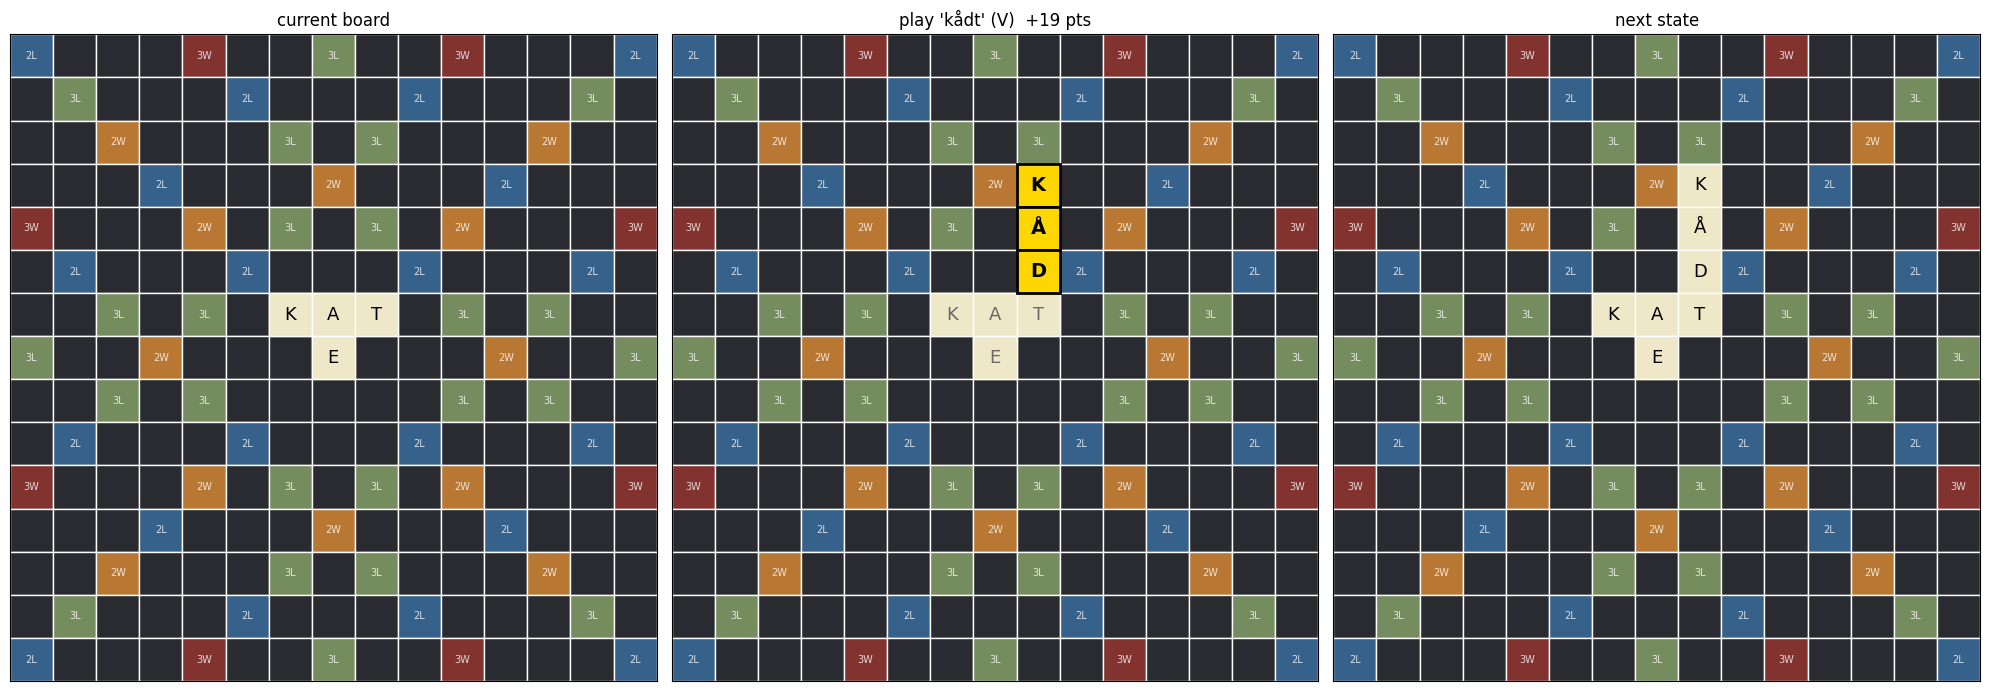

In [4]:
from src.move_generator import plot_board

# Current board, the proposed best move highlighted, and the resulting state.
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
plot_board(letters, bonus, ax=axes[0], title="current board")
plot_board(letters, bonus, move=best, ax=axes[1],
           title=f"play '{best.word}' ({best.direction})  +{best.score} pts")
plot_board(next_letters, bonus, ax=axes[2], title="next state")
plt.tight_layout()
plt.show()


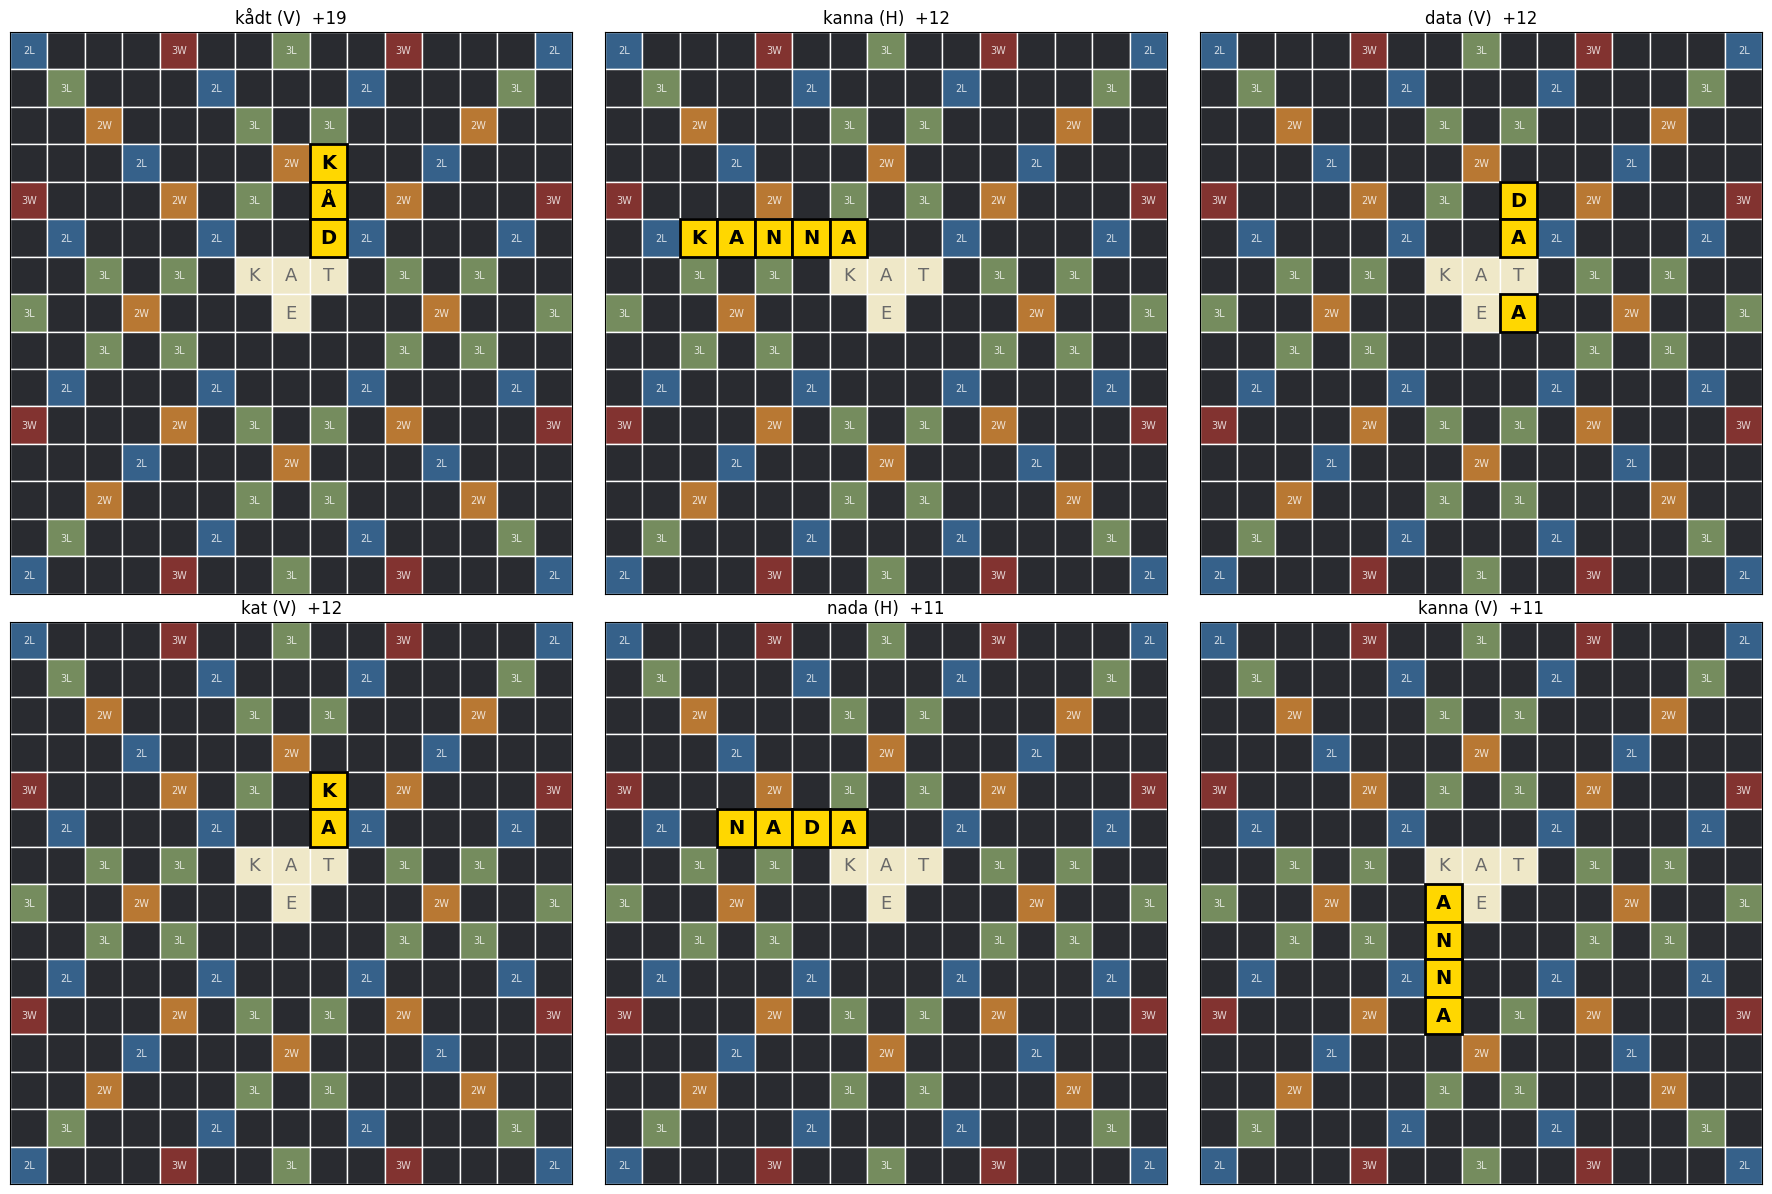

In [5]:
# Top candidate moves, ranked by score.
top = moves[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for m, ax in zip(top, axes.ravel()):
    plot_board(letters, bonus, move=m, ax=ax,
               title=f"{m.word} ({m.direction})  +{m.score}")
for ax in axes.ravel()[len(top):]:
    ax.axis("off")
plt.tight_layout()
plt.show()
